# 02 — One pump up close + the 2x-volume hypothesis

Part A: draw ONE concrete pump, show where each condition fires and how dedup
collapses many raw triggers into a single event.

Part B: test the hypothesis — *after volume doubles, how often does price keep
rising over the next hour?* — and compare it to the baseline (no condition).

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

SYMBOL = '1000PEPEUSDT'
df = ohlcv(SYMBOL, '2024-06-01', '2024-12-01', tf='1min')

# ----- the same two detector signals as notebook 01 -----
W = 15
ret15 = df['close'].pct_change(W)                              # price condition
vol_med = df['volume'].rolling(240, min_periods=60).median()
vol_surge = df['volume'].rolling(W).sum() / (vol_med * W)      # volume condition (15m)

RET_TH, VOL_TH = 0.05, 3.0
cond_price = ret15 > RET_TH
cond_vol   = vol_surge > VOL_TH
both = cond_price & cond_vol
print('minutes where BOTH conditions fire (raw triggers):', int(both.sum()))

minutes where BOTH conditions fire (raw triggers): 107


## Part A — one pump up close

raw triggers in this window: 43  ->  collapses to 1 event at 13:31
[saved] notebooks\_out\02_one_pump.png


WindowsPath('C:/projects/researchlab/notebooks/_out/02_one_pump.png')

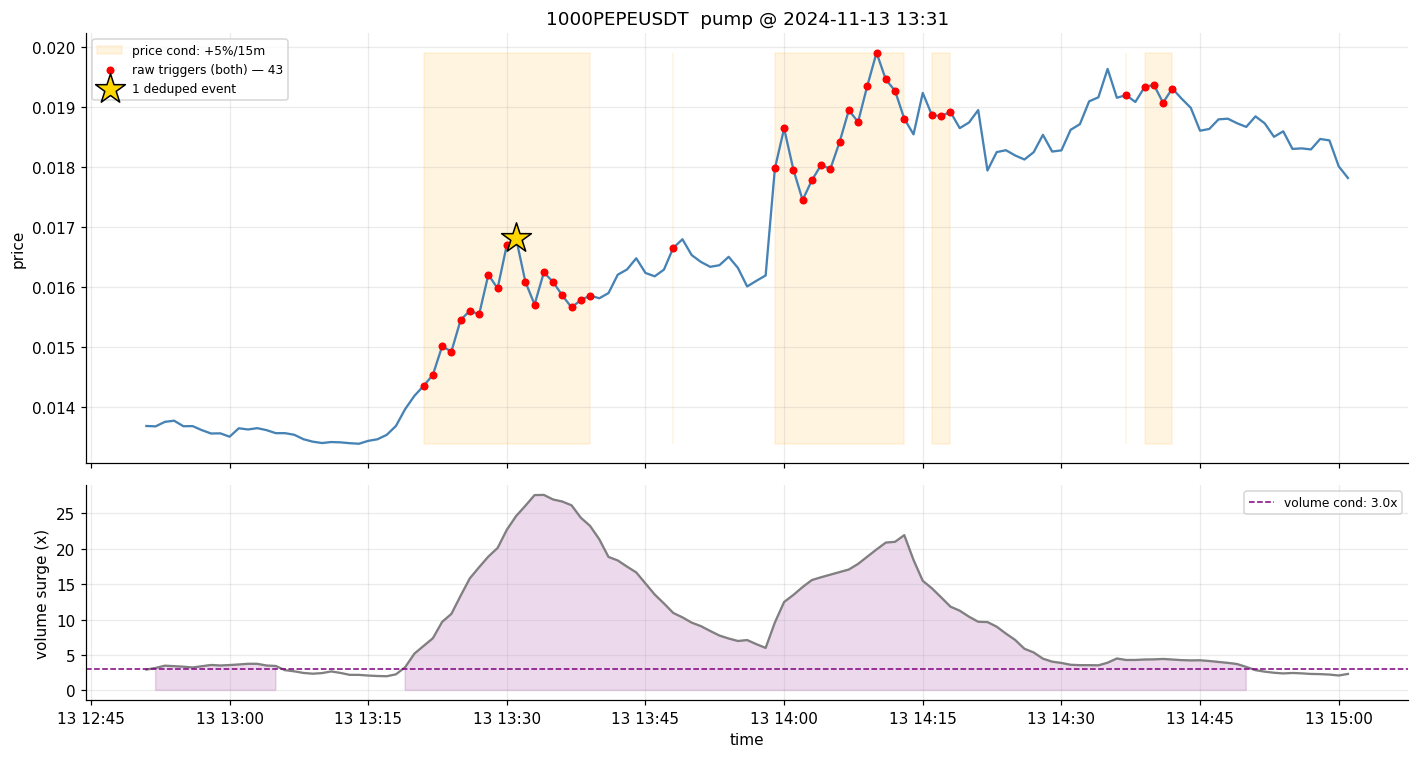

In [2]:
# zoom on the big 2024-11-13 pump
anchor = pd.Timestamp('2024-11-13 13:31', tz='UTC')
lo = anchor - pd.Timedelta(minutes=40)
hi = anchor + pd.Timedelta(minutes=90)
win = df.loc[lo:hi]
wr  = ret15.loc[lo:hi]
wv  = vol_surge.loc[lo:hi]
wboth = both.loc[lo:hi]

# raw trigger minutes inside this window, and the single deduped anchor (strongest)
raw_trigs = wboth[wboth].index
event_anchor = wr.loc[raw_trigs].idxmax() if len(raw_trigs) else anchor
print(f'raw triggers in this window: {len(raw_trigs)}  ->  collapses to 1 event at {event_anchor:%H:%M}')

fig, (axp, axv) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

# --- price panel ---
axp.plot(win.index, win['close'], color='steelblue')
axp.fill_between(win.index, win['close'].min(), win['close'].max(),
                 where=(wr > RET_TH).reindex(win.index, fill_value=False),
                 color='orange', alpha=0.12, label='price cond: +5%/15m')
axp.scatter(raw_trigs, win['close'].reindex(raw_trigs), color='red', s=18, zorder=5,
            label=f'raw triggers (both) — {len(raw_trigs)}')
axp.scatter([event_anchor], [win['close'].loc[event_anchor]], marker='*',
            s=420, color='gold', edgecolor='k', zorder=6, label='1 deduped event')
axp.set_ylabel('price'); axp.set_title(f'{SYMBOL}  pump @ {anchor:%Y-%m-%d %H:%M}')
axp.legend(loc='upper left', fontsize=8)

# --- volume-surge panel ---
axv.plot(win.index, wv, color='gray')
axv.axhline(VOL_TH, color='purple', ls='--', lw=1, label=f'volume cond: {VOL_TH}x')
axv.fill_between(win.index, 0, wv, where=(wv > VOL_TH), color='purple', alpha=0.15)
axv.set_ylabel('volume surge (x)'); axv.set_xlabel('time'); axv.legend(fontsize=8)
show('02_one_pump')

## Part B — the 2x-volume hypothesis

Condition: this minute's volume > 2x the typical (rolling-median) minute volume.
Question: after that, is price higher 1 hour later?

**The honest check:** we don't just look at the conditional rate, we compare it
to the **baseline** — how often price is higher 1h later at *any* random minute.
If 2x-volume gives ~the same number as baseline, the signal tells us nothing.

In [3]:
H = 60
fwd = df['close'].shift(-H) / df['close'] - 1.0     # return over the NEXT hour
vol_ratio = df['volume'] / vol_med                  # this minute's volume vs typical
valid = fwd.notna() & vol_ratio.notna()

base_up = (fwd[valid] > 0).mean()
print(f'BASELINE  (any minute):   price higher in 1h = {base_up*100:.1f}%   '
      f'mean fwd ret {fwd[valid].mean()*100:+.3f}%\n')

print('CONDITIONAL on volume multiple:')
print(f"{'cond':>10} {'n':>8} {'P(up in 1h)':>14} {'mean fwd ret':>14}")
for k in [2, 3, 5, 10]:
    m = valid & (vol_ratio > k)
    up = (fwd[m] > 0).mean()
    print(f"vol>{k:>2}x  {int(m.sum()):>8} {up*100:>12.1f}% {fwd[m].mean()*100:>13.3f}%")

BASELINE  (any minute):   price higher in 1h = 49.8%   mean fwd ret +0.018%

CONDITIONAL on volume multiple:
      cond        n    P(up in 1h)   mean fwd ret
vol> 2x     60204         49.4%         0.030%
vol> 3x     33860         49.6%         0.044%
vol> 5x     14625         49.9%         0.099%
vol>10x      3915         50.8%         0.216%


In [4]:
# does it matter whether the 2x-volume minute was itself an UP minute or a DOWN minute?
min_ret = df['close'].pct_change()      # this single minute's direction
for label, extra in [('2x vol & up minute', min_ret > 0), ('2x vol & down minute', min_ret < 0)]:
    m = valid & (vol_ratio > 2) & extra
    up = (fwd[m] > 0).mean()
    print(f'{label:>22}:  n={int(m.sum()):>6}   P(up in 1h)={up*100:.1f}%   '
          f'mean fwd {fwd[m].mean()*100:+.3f}%')

    2x vol & up minute:  n= 29594   P(up in 1h)=48.0%   mean fwd +0.010%
  2x vol & down minute:  n= 30497   P(up in 1h)=50.7%   mean fwd +0.049%
